# STUAART: Continuous Multi-Day Mass Active VS Inactive Identification

This Google Colab notebook is designed to identify active (exploratory, displacement behaviours) and inactive (sleeping, calm behaviours) moments on scales from the mass data collected by the STUAART system.

Key Features:
- Multi-Day Continuity: Merges data from multiple daily CSV files into a single, linearized timeline.  
- Absolute Clock Alignment: Automatically calculates offsets based on the experiment's start time to view data in cumulative clock time format.  
- Signal Processing: Includes built-in convolution filters to smooth raw data and highlight underlying trends.  
- Flexible Windows: Supports precise "zooming" into specific hours or days using either relative time or clock-time strings.  

Instructions:
1. Ensure your raw STUAART CSV files are uploaded to your Google Drive.  
2. Update the file paths and experimental parameters in Step 2.  
3. Run all cells to generate individual scale plots and a combined smoothed mass trend.  

Note that you must run your raw data in *Remove buffer flush indicators in raw data.ipynb* before running this Colab.

# 1. Setup and Libraries

This cell imports the necessary Python libraries for data manipulation (pandas, numpy), visualization (matplotlib), and file system management.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math
from pathlib import Path
from itertools import groupby
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d

# Step 2 : User configuration and Drive mounting

**The user must define these variables :**
1. Paths:
 - Change `project_directory` and `data_path `to point to your data in your Google Drive.

2. Visualisation:
 - `color_scales` : Defines the color of each scale.
 - `save_figure` : If True, figures are saved in a new folder *Figures*.
 - `figure_format` : A string that defines in which format you want your figures to be saved ("eps", "png", etc.)

3. Location identification:
 - `time_window` : Defines range of display. Use *None* to display the full duration, a tuple of numbers for **relative time** (e.g. (0,5)), or a tuple of strings for **absolute clock time** (e.g. ("8:00","12:00")).
 - `bins` : Defines the time (float) to bin the location data. Parameters such as `number_of_entries_per_bin_per_scale`, `average_time_spent_per_bin_per_scale`, `std_time_sent_per_bin_per_scale` and `relative_time_sent_per_bin_per_scale` are computed considering the time bin defined here. For example, 0.5 is 30 minutes.
  - `days` : A list of days to visualise (e.g. [1,2] or ["2026.04.01"]). Note that this variable must be a list even if only one day is selected.

4. Ground truth location (optional):
  - `ground_truth_file` : Defines the path where to find the location indicators per scale done manually by the experimenter. The CSV file should have the first column as the time stamps, and the following columns as an indicator, either 0 or 1, of the presence of the animal on the scale. This is done after, for example, video recording the STUAART to validate the performances of this notebook to identify the animal's location.

5. Ground truth mass (optional):
  - `manual_mass` : Add your manual scale measurements here as a list of tuples in the format (day, time, mass). The day can be either integers (e.g. 1) or strings (e.g. "2026.04.01"). The time can either be integers/floats (for relative time) or strings (for absolute clock time in the format "HH:MM")

`debug_mode` : If True, prints more informations for the user.

`save_figures` : If True, saves the figures in a folder called *Figures* in the figure format defined with `figure_format`.

`plot_figures` : If True, plots the figures in addition of printing the location computation parameter values.


After configuring these variables, the next cell will prompt you to mount your Google Drive to grant access to the files.

**Careful** : If `save_figure` is True but `plot_figure` is False, an error will occur.

In [25]:
# Change these variables
project_directory = "/content/drive/My Drive/DCCM_Lab/labdata/vpineaunoel/stuaart"
data_path = project_directory + "/20260730-3MiceInSTUAARTs_5/Pink/WithoutBufferFlushes-BaselineCorrectedAndOutlierRemoval-DBSCANwithManualCorrections/"
color_scales = ["b", "r", "g"]
save_figure = True
save_data = False
save_suffix = "Pink5-20260802-15h00"
debug_mode = True
plot_figures = True
time_acquired_with_millis = False
bins = 0.166666666666 # time to bin the data for location in float. For example, 0.5 is 30 minutes.
time_window = ["14:00", "15:00"] # is either (number, number) for relative time, (str, str) for absolute clock time or None to display all data of the day
days = [4] # is either the day number (starting from 1) of the date in the format "YYYY.MM.DD". Must be a list.
sampling_rate = 80
figure_format = "pdf"
time_when_day_starts_end_ends = [7, 19]

ground_truth_file = project_directory + "/20260730-3MiceInSTUAARTs_5/Pink/CalmGroundTruth/20260802-RecordingPink-Around15h00-DONE-GroundTruthCalmIndicatorPerSecond.csv"
delay = -0.944

# Add in the list the real mass measurements done during the experiment.
# Format : (day, time, mass)
# manual_mass = [
#     (2, "16:00", 24.7)
#     ]
manual_mass = None

In [26]:
from google.colab import drive
drive.mount('/content/drive/')
os.chdir(project_directory)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# 3. File Indexing and Date Extraction

This cell scans the provided data directory and sorts the CSV files. It automatically extracts the acquisition dates and assigns a relative day number (1, 2, 3...) to each file based on the filename prefix (e.g., YYYY.MM.DD-metadata.csv). This indexing allows the script to correctly map your selection in the days variable to the physical files on the drive.

In [27]:
files = os.listdir(data_path)
files.sort()

dates_of_experiment = []
relative_days_of_experiment = []
i = 1
for file in files: # put in order the dates of the experiments based on the beginning of the CSV file names.
  if file.endswith(".csv"):
    index_first_dash = file.find("-")
    dates_of_experiment.append(file[:index_first_dash])
    relative_days_of_experiment.append(i)
    i += 1

if debug_mode:
  print("Dates of experiment : ", dates_of_experiment)
  print("Relative days of experiment : ", relative_days_of_experiment)

Dates of experiment :  ['2026.07.30', '2026.07.31', '2026.08.01', '2026.08.02', '2026.08.03', '2026.08.04']
Relative days of experiment :  [1, 2, 3, 4, 5, 6]


# 4. Time Mode Identification

This cell identifies the time mode according to the format of *time_window*.

- If *time_window* are strings (such as ("8:00","12:00")), *clock_time* is True.
- If *time_window* are integers/floats (such as (1.5, 2)), *clock_time* is False.
- If *time_window* is None, *clock_time* is None.

In [28]:
if time_window is None: # no time window selected
  clock_time = False
elif all(isinstance(i, (int, float)) for i in time_window): # relative time
  clock_time = False
elif all(isinstance(i, (str)) for i in time_window): # absolute clock time
  clock_time = True

if debug_mode:
  print("Time window : ", time_window)
  print("Clock time : ", clock_time)

Time window :  ['14:00', '15:00']
Clock time :  True


# 5. Linearizing the Time Window and Format Days

To allow for seamless visualization across multiple days, this cell "linearizes" your time selection. If you are using absolute clock time (e.g., from 15:00 on Day 1 to 10:00 on Day 2), the script converts these strings into a continuous float value. It achieves this by (1) converting "HH:MM" strings into decimal hours and (2) adding an offset of 24 hours for every day elapsed since the start of the experiment. For example, "02:00" on Day 2 becomes 26.0 hours ($2 + 24$). This creates a single, continuous timeline, making it possible to zoom into specific periods that span across midnight without breaking the data processing logic.

Additionally, the definition of days depends on the context and is fixed here. If both days and time_window are None, the entire time series across all days is considered. If days is None but time_window is provided, only the first day is considered.

Finally, the script calculates a start_shift based on the first file of the entire experiment (files[0]). This calculation ensures that the clock time remains consistent across all loaded files, allowing the script to correctly map all timestamps to the actual time of day.   

In [29]:
def str_to_float_hour(time_str):
    """Convert str hour in the format 00:00 to a float value"""
    hours, minutes = map(int, time_str.split(':'))
    return hours + (minutes / 60.0)


def format_time_window_and_days(time_window, days, dates_of_experiment, relative_days_of_experiment, start_shift):
  if days is None and time_window is not None: # if no day is specified, but a time window is, the first day is considered
    days = [1]

  elif days is None and time_window is None: # if days and time_window are None, considers all data
    days = relative_days_of_experiment
    time_window = (0, 24)

  elif days is not None and time_window is None: # if time_window is None, all days defined in days are considered
    time_window = (0, 24)

  # Access first and last day of days
  start_day = days[0]
  end_day = days[-1]
  if all(isinstance(day, (int, float)) for day in days):
    formatted_start_day = days[0]
    formatted_end_day = days[-1]
  elif all(isinstance(day, str) for day in days):
    formatted_start_day = dates_of_experiment.index(days[0]) + 1
    formatted_end_day = dates_of_experiment.index(days[-1]) + 1
  else:
    raise ErrorValue("Days is not ints or strings. Verify the definition of days in cell 2.")

  if all(isinstance(time, (int, float)) for time in time_window):
    start_time_in_float = time_window[0] + start_shift
    end_time_in_float = time_window[1] + start_shift
  elif all(isinstance(time, str) for time in time_window):
    start_time_in_float = str_to_float_hour(time_window[0])
    end_time_in_float = str_to_float_hour(time_window[1])

  new_start_time = start_time_in_float + ((formatted_start_day-1) * 24)
  new_end_time = end_time_in_float + ((formatted_end_day-1) * 24)

  if debug_mode:
    print("Start time : ", start_time_in_float)
    print("End time : ", end_time_in_float)
    print("Formatted start day : ", formatted_start_day)
    print("Formatted end day : ", formatted_end_day)
    print("Time window after formatting : ", (new_start_time, new_end_time))
    print("Selected days : ", days)

  return days, (new_start_time, new_end_time)


def format_day_times(time_when_night_start_and_end, days, time_window):
  formatted_day_times = []
  for day in days:
    formatted_day_times.append((time_when_night_start_and_end[0] + ((day-1) * 24), time_when_night_start_and_end[1] + ((day-1) * 24)))
  return formatted_day_times

# compute start shift according to the time the experiment started on the first day
if time_acquired_with_millis:
  absolute_first_file = data_path + files[0]
  first_data = pd.read_csv(absolute_first_file)
  first_duration = first_data.iloc[-1, 0] / (1000 * 60 * 60)
  start_shift = (24.0 - first_duration) % 24
else:
  start_shift = 0

if debug_mode:
  print("Start shift : ", start_shift)

days, time_window = format_time_window_and_days(time_window=time_window, days=days, dates_of_experiment=dates_of_experiment, relative_days_of_experiment=relative_days_of_experiment, start_shift=start_shift)
day_times_per_day = format_day_times(time_when_night_start_and_end=time_when_day_starts_end_ends, days=days, time_window=time_window)

Start shift :  0
Start time :  14.0
End time :  15.0
Formatted start day :  4
Formatted end day :  4
Time window after formatting :  (86.0, 87.0)
Selected days :  [4]


# 6. Data Loading and Global Alignment

This cell performs the core data aggregation and temporal alignment required for multi-day analysis.

1. Global Clock Alignment: The previously computed start_shift is used to align the time to the absolute clock time.   
2. Data Accumulation Loop: It iterates through your selected days, identifying the correct file paths whether you provided day numbers or specific dates. It then extracts the raw millisecond data, converts it into decimal hours, and applies the global shift to the dataset of each day.  
3. Merging and Filtering: All selected data points are merged into two primary arrays: *time_hour* and *mass_data*. Finally, the script uses a boolean mask to filter these arrays, retaining only the measurements that fall precisely within your defined *time_window*. This process enables the seamless visualization of a continuous timeline, even when the data spans across multiple files.

In [30]:
all_time_hour = []
all_mass_data = []

if len(days) > 1:
  all_days = range(days[0], days[-1]+1, 1)
else:
  all_days = days

for d in all_days:
  if type(d) == str:
      actual_day_index = dates_of_experiment.index(d) # ex: 0, 1, 2...
      current_data_path = data_path + files[actual_day_index]
  else:
      actual_day_index = d - 1
      current_data_path = data_path + files[actual_day_index]

  if debug_mode:
    print("Data path : ", current_data_path)
  data = np.array(pd.read_csv(current_data_path))
  time = data[:,0]

  if time_acquired_with_millis:
    current_time_hour = time/(1000 * 60 * 60)
    current_time_hour = (start_shift + current_time_hour)
  else:
    current_time_hour = time

  current_mass_data = data[:, 1:]

  all_time_hour.append(current_time_hour)
  all_mass_data.append(current_mass_data)

print("All time hour : ", all_time_hour, len(all_time_hour), all_time_hour[0].shape)
# all data is contained in time_hour and mass_data after these two lines
time_hour = np.concatenate(all_time_hour)
mass_data = np.concatenate(all_mass_data, axis=0)

if time_acquired_with_millis is False:
  diffs = np.diff(time_hour)
  rollover_next_day = diffs < -12.0
  rollovers = np.concatenate(([False], rollover_next_day))
  days_passed = np.cumsum(rollovers)
  print("rollovers : ", rollovers, rollovers.shape, np.unique(rollovers))
  if 1.0 in all_days and np.any(rollovers):
    time_hour = time_hour + (days_passed * 24.0)
  elif not np.any(rollovers):
    time_hour = time_hour + ((d-1) * 24.0)
  else:
    indices_to_remove = np.where(days_passed == 0)[0]
    mass_data = np.delete(mass_data, indices_to_remove, axis=0)
    time_hour = np.delete(time_hour, indices_to_remove)
    time_hour = time_hour + ((d-1) * 24.0)

print(f"Beginning {time_hour[0]:.3f} and end {time_hour[-1]:.3f} value of time overall.")

mask = (time_hour >= time_window[0]) & (time_hour <= time_window[1])
time_in_window_hour = time_hour[mask]
mass_data_in_window = mass_data[mask, :]

# Initialize a mask of all True (Assume everything is night)
is_night = np.ones(len(time_in_window_hour), dtype=bool)
for day_start, day_end in day_times_per_day:
    is_day = (time_in_window_hour >= day_start) & (time_in_window_hour <= day_end)
    is_night[is_day] = False
night_indicator_list = is_night.astype(int)

if debug_mode:
    print("Time window input : ", time_window)
    if len(time_hour) > 0:
      print(f"Time window in absolute clock time : Start {time_in_window_hour[0]:.3f} and End {time_in_window_hour[-1]:.3f}")
    else:
      print("No data found in mask")

    print("Time_hour : ", time_hour, time_hour.shape)
    print(f"Time_hour_in_window : {time_in_window_hour}{time_in_window_hour.shape}")
    print("Mass_data : ", mass_data_in_window, mass_data_in_window.shape)
    print("Night indicator list : ", np.unique(night_indicator_list), night_indicator_list.shape)

Data path :  /content/drive/My Drive/DCCM_Lab/labdata/vpineaunoel/stuaart/20260730-3MiceInSTUAARTs_5/Pink/WithoutBufferFlushes-BaselineCorrectedAndOutlierRemoval-DBSCANwithManualCorrections/2026.08.02-WithoutBufferFlushes-BaselineCorrectedAndOutlierRemoval-DBSCAN-BinSize-1.0.csv
All time hour :  [array([2.39998808e+01, 1.61944444e-04, 1.65000000e-04, ...,
       2.39998292e+01, 2.39998322e+01, 2.39998356e+01])] 1 (7342814,)
rollovers :  [False  True False ... False False False] (7342814,) [False  True]
Beginning 72.000 and end 96.000 value of time overall.
Time window input :  (86.0, 87.0)
Time window in absolute clock time : Start 86.000 and End 87.000
Time_hour :  [72.00016194 72.000165   72.00016806 ... 95.99982917 95.99983222
 95.99983556] (7342813,)
Time_hour_in_window : [86.0001125  86.00011583 86.00011889 ... 86.99974472 86.99974806
 86.99975111](305666,)
Mass_data :  [[6.07000017e+00 3.58949995e+00 2.15196285e+01]
 [5.97000027e+00 2.95399952e+00 2.13414021e+01]
 [6.03000021e+00

# 7. Processing and Filtering Manual Measurements (Ground Truth)

This cell handles the manual scale measurements (ground truth) provided by the user, ensuring they are correctly positioned on the continuous multi-day timeline.

1. Time Linearization (*format_manual_mass()*): Just as the raw data was shifted to create a continuous timeline, this function converts the *manual_mass* tuples into linearized values. It identifies the correct day of the experiment and adds a 24-hour offset for each elapsed day. This ensures that a manual weighing at 10:00 AM on Day 2 is accurately mapped to Hour 34.0 on the graph.  
2. Window Filtering (*filter_manual_measurements()*): This function sifts through the linearized manual measurements and retains only those that fall within your *time_window*.  

Output: The resulting *real_mass* variable contains the specific data points that will be overlaid on the final plot for visual validation of the STUAART accuracy to track the mass.

In [31]:
def filter_manual_measurements(measurements, current_days, dates_of_experiment, current_window, is_clock_mode):
  filtered_times = []
  filtered_masses = []

  for m_time, m_mass in measurements:
    # convert time in float
    if isinstance(m_time, str):
      t_float = str_to_float_hour(m_time) # function defined in that last cell
    else:
      t_float = m_time # relative time is kept as is

    # check time
    if current_window is not None:
      w_start = str_to_float_hour(current_window[0]) if isinstance(current_window[0], str) else current_window[0]
      w_end = str_to_float_hour(current_window[1]) if isinstance(current_window[1], str) else current_window[1]

    if not (w_start <= t_float <= w_end):
      continue

    filtered_times.append(t_float)
    filtered_masses.append(m_mass)

  return filtered_times, filtered_masses


def format_manual_mass(manual_mass, dates_of_experiment, relative_days_of_experiment, start_shift):
  if manual_mass is None:
    return None
  else:
    new_manual_mass = []
    for m_day, m_time, m_mass in manual_mass:
      if isinstance(m_day, (int, float)):
        new_day = relative_days_of_experiment[m_day-1]
      elif isinstance(m_day, str):
        new_day = dates_of_experiment.index(m_day) + 1

      if isinstance(m_time, str):
        time_in_float = str_to_float_hour(m_time)
      else:
        time_in_float = m_time + start_shift

      new_time = time_in_float + ((new_day-1) * 24)
      new_manual_mass.append((new_time, m_mass))

  return new_manual_mass


if manual_mass is not None:
  if debug_mode:
    print("Manual mass as input : ", manual_mass)
    print("Type of manual mass : ", type(manual_mass))
    print("Current days : ", days)
    print("Current time window : ", time_window, type(time_window))

  new_manual_mass = format_manual_mass(manual_mass=manual_mass, dates_of_experiment=dates_of_experiment, relative_days_of_experiment=relative_days_of_experiment, start_shift=start_shift)
  real_mass = filter_manual_measurements(measurements=new_manual_mass, current_days=days, dates_of_experiment=dates_of_experiment, current_window=time_window, is_clock_mode=clock_time)

  if debug_mode:
    print("Real mass after formatting : ", new_manual_mass)
    print("Real mass after filtering with time_window : ", real_mass)

else:
  real_mass = None

# 8. Total Mass Computation

This cell calculates the total mass of the entire STUAART. `sum_data_over_time()` sums the values from all scales at each timestamp to provide a single total cage mass measurement.  


In [32]:
def sum_data_over_time(data_per_scale):
  """
  Sum data per time point to obtain the mass measurement over time of the whole cage system (and not only per scale).
  """
  summed_data = np.nansum(data_per_scale, axis=1)
  return summed_data

summed_data_in_window = sum_data_over_time(data_per_scale=mass_data_in_window)

if debug_mode:
  print("Shape of mass data before summing mass over every timestamp: ", mass_data_in_window.shape)
  print("Shape of summed data : ", summed_data_in_window.shape)
  print("Shape of time : ", time_in_window_hour.shape)

Shape of mass data before summing mass over every timestamp:  (305666, 3)
Shape of summed data :  (305666,)
Shape of time :  (305666,)


# 9. Core Analysis Pipeline

This cell serves as the primary computational engine for the script. It defines the core helper functions required to clean raw mass signals, track the mouse's physical location, extract active VS inactive bouts, and aggregate daily statistics of activity, followed by the main execution block that processes the data window. Additionnaly, this cell uses memory-optimized moving averages (`convolution_filter_with_padding_edge_average_per_scale()`) and rolling variance (`rolling_variance()`) to smooth time-series data and highlight behavioral shifts.

First, this cell maps the animal's presence and entry frequencies across individual scales over time (`compute_location_on_scale()`). It then smooths binary activity indicators, resolves edge-case states (`extract_bout_metrics()`, `find_bouts_by_smoothing()`), and compiles daily metrics like event counts, total durations, and mean bout lengths of active VS inactive events (`compute_daily_summary()`).

In [33]:
def when_mouse_is_in(time, data, sampling_rate):
  """
  Identifies the moment when the mouse is in the cage.
  Data acquisition starts with a plateau at 0g. When the mouse is in, the mean mass goes up.
  Creates two class variables with the time and the mass data when the mouse is in.
  """
  length = sampling_rate
  for i in range(data.shape[0]):
    mean = np.nanmean(data[i: i+length])
    if np.isclose(mean, 0, atol=3): # + or - one gram is still considered at 0g.
      i += length
    else:
      break
  time_when_mouse_is_in = time[i+length]

  return time_when_mouse_is_in


def convolution_filter_with_padding_edge_average_per_scale(data_per_scale, length: int = 10, iteration: int = 1):
  """
  Convolution filter on the signal per scale. This filter is meant to smooth up the signal
  and remove outliers without any threshold. The edges are padded to correct for boundary effects.

  Parameters:
  - length: length of the kernel to convolve on signal. default is 40
  - iteration: number of consecutive convolutions to do. default is 1
  """
  if iteration <= 0:
    raise ValueError("Number of iteration cannot be under 1")
  current_data = data_per_scale.astype(np.float32, copy=True)

  for _ in range(iteration):
    valid_mask = ~np.isnan(current_data)
    data_filled = np.nan_to_num(current_data, nan=0.0)
    moving_sum = uniform_filter1d(data_filled, size=length, axis=0, mode='nearest') * length
    moving_count = uniform_filter1d(valid_mask.astype(np.float32), size=length, axis=0, mode='nearest') * length
    with np.errstate(divide='ignore', invalid='ignore'):
      current_data = moving_sum / moving_count
      current_data[moving_count == 0] = np.nan

  return current_data


def compute_location_on_scale(time, data_per_scale, summed_data, sampling_rate, bins: float = 0.5, first_day: bool = False):
  """
  Time series of mass per individual scale are used to identify where the mouse is over time.
  After a simple average convolution, the mouse is identified as present on a scale if
  mass is outside noise threshold (-5 to 5g).
  """
  convolved_data = convolution_filter_with_padding_edge_average_per_scale(data_per_scale=data_per_scale, length=10)
  presence_indicator_per_scale = np.ones(shape=convolved_data.shape)
  number_of_scales = convolved_data.shape[1]

  if first_day:
    time_when_mouse_is_in = when_mouse_is_in(time=time, data=summed_data, sampling_rate=sampling_rate)
    index_when_mouse_is_in = np.argmin(np.abs(time - time_when_mouse_is_in))
    presence_indicator_per_scale[:index_when_mouse_is_in, :] = 0

  print("Convolving mass data per scale for location identification.")
  for n in range(number_of_scales):
    index_data_around_zero = np.where((convolved_data[:, n] > -5) & (convolved_data[:, n] < 5))[0]
    presence_indicator_per_scale[index_data_around_zero, n] = 0

  number_of_entries_per_bin_per_scale = []
  bin_edges = np.arange(time[0], time[-1] + bins, bins)

  for n in range(number_of_scales):
    number_of_entries = []
    for start_t, end_t in zip(bin_edges[:-1], bin_edges[1:]):
      # Include start edge: start_t <= time < end_t
      mask = (time >= start_t) & (time < end_t)
      slice_data = presence_indicator_per_scale[mask, n]
      # Guard against empty intervals
      if slice_data.size == 0:
        number_of_entries.append(0)
        continue

      num_entries = sum(1 for key, _ in groupby(slice_data) if key == 1)
      number_of_entries.append(num_entries)

    number_of_entries_per_bin_per_scale.append(np.array(number_of_entries))

  return convolved_data, presence_indicator_per_scale, np.array(number_of_entries_per_bin_per_scale)


def extract_bout_metrics(active_mask, time_array):
  """
  Extracts start times, end times, and durations for both active and
  inactive bouts, properly handling edge cases where states start or
  end at the boundaries of the time series.
  """
  # Active
  active_changes = np.diff(active_mask.astype(int))
  start_indices_active = np.where(active_changes == 1)[0] + 1
  end_indices_active = np.where(active_changes == -1)[0] + 1

  if active_mask[0]:
    start_indices_active = np.insert(start_indices_active, 0, 0)
  if active_mask[-1]:
    end_indices_active = np.append(end_indices_active, len(time_array) - 1)

  durations_active = time_array[end_indices_active] - time_array[start_indices_active]
  active_bouts = {'start_time': time_array[start_indices_active], 'end_time': time_array[end_indices_active], 'duration': durations_active}

  # Inactive
  inactive_mask = ~active_mask
  inactive_changes = np.diff(inactive_mask.astype(int))
  start_indices_inactive = np.where(inactive_changes == 1)[0] + 1
  end_indices_inactive = np.where(inactive_changes == -1)[0] + 1

  if inactive_mask[0]:
    start_indices_inactive = np.insert(start_indices_inactive, 0, 0)
  if inactive_mask[-1]:
    end_indices_inactive = np.append(end_indices_inactive, len(time_array) - 1)

  durations_inactive = time_array[end_indices_inactive] - time_array[start_indices_inactive]
  inactive_bouts = {'start_time': time_array[start_indices_inactive],'end_time': time_array[end_indices_inactive],'duration': durations_inactive}

  return active_bouts, inactive_bouts


def find_bouts_by_smoothing(binary_array, time_array, window_size=150, threshold=0.1):
  """
  Smooth a binary array to get local density, then find local maxima accoridng to a threshold.
  The smoothened array is used to extract the bouts metrics, which are saved in a dictionary.
  Returns the smoothened array (active_mask) and the bouts dictionary.
  """
  print("Smoothing activity indicator array and identifying active and inactive events.")
  smoothed = uniform_filter1d(binary_array.astype(float), size=window_size, mode='reflect')
  active_mask = smoothed > threshold
  active_bouts, inactive_bouts = extract_bout_metrics(active_mask=active_mask, time_array=time_array)
  return active_mask, active_bouts, inactive_bouts


def rolling_variance(array, window_size):
  """
  Computes the rolling variance of an array using convolution.
  array: 1D numpy array (time-series data)
  window_size: int, the size of the sliding time window
  Returns variance, a 1D numpy array of the same shape (using 'same' mode)
  """
  # uniform kernel
  kernel = np.ones(window_size) / window_size

  print("Performing rolling variance.")
  # Compute E[x] and E[x^2] via convolution
  mean_array = np.convolve(array, kernel, mode='same')
  mean_array2 = np.convolve(array**2, kernel, mode='same')

  # Variance = E[x^2] - (E[x])^2
  variance = mean_array2 - mean_array**2

  # Optional cleanup for floating-point inaccuracies where variance might dip slightly below 0
  variance[variance < 0] = 0

  return variance


def compute_daily_summary(active_bouts, inactive_bouts):
  """
  Computes daily summary statistics and metrics for active and inactive behavioral bouts grouped by experimental days.

  Parameters:
  - active_bouts (dict): Dictionary containing keys 'start_time', 'end_time', and 'duration' for active bouts.
  - inactive_bouts (dict): Dictionary containing keys 'start_time', 'end_time', and 'duration' for inactive bouts.

  Returns:
  - dict: A dictionary containing aggregated daily metrics:
    - 'All days': List of all unique experimental days identified.
    - 'Active events': Number of active events per day.
    - 'Inactive events': Number of inactive events per day.
    - 'Active time': Total duration of active events per day.
    - 'Inactive time': Total duration of inactive events per day.
    - 'Mean active bouts': Mean duration metrics of active bouts per day.
    - 'Mean inactive bouts': Mean duration metrics of inactive bouts per day.
    - 'Std active bouts': Standard deviation of active bout metrics per day.
    - 'Std inactive bouts': Standard deviation of inactive bout metrics per day.
  """
  days_of_experiment_active = np.unique(np.floor(active_bouts["start_time"]/24)+1)
  days_of_experiment_inactive = np.unique(np.floor(inactive_bouts["start_time"]/24)+1)

  daily_summary = {"All days": list(set(days_of_experiment_active) | set(days_of_experiment_inactive))}
  number_of_active_events_per_day = []
  number_of_inactive_events_per_day = []
  total_time_of_active_events_per_day = []
  total_time_of_inactive_events_per_day = []
  mean_active_bouts_per_day = []
  mean_inactive_bouts_per_day = []
  std_active_bouts_per_day = []
  std_inactive_bouts_per_day = []
  for day in days_of_experiment_active:
    indices_of_day = np.where(days_of_experiment_active == day)[0]

    number_of_active_events = active_bouts["start_time"][indices_of_day].shape[0]
    number_of_active_events_per_day.append(number_of_active_events)
    total_time_of_active_events = np.sum(active_bouts["duration"][indices_of_day])
    total_time_of_active_events_per_day.append(total_time_of_active_events)
    mean_active_bouts = np.mean(total_time_of_active_events/number_of_active_events_per_day)
    std_active_bouts = np.std(total_time_of_active_events/number_of_active_events_per_day)
    mean_active_bouts_per_day.append(mean_active_bouts)
    std_active_bouts_per_day.append(std_active_bouts)

    number_of_inactive_events = inactive_bouts["start_time"][indices_of_day].shape[0]
    number_of_inactive_events_per_day.append(number_of_inactive_events)
    total_time_of_inactive_events = np.sum(inactive_bouts["duration"][indices_of_day])
    total_time_of_inactive_events_per_day.append(total_time_of_inactive_events)
    mean_inactive_bouts = np.mean(total_time_of_inactive_events/number_of_inactive_events_per_day)
    std_inactive_bouts = np.std(total_time_of_inactive_events/number_of_inactive_events_per_day)
    mean_inactive_bouts_per_day.append(mean_inactive_bouts)
    std_inactive_bouts_per_day.append(std_inactive_bouts)

  daily_summary["Active events"] = number_of_active_events_per_day
  daily_summary["Inactive events"] = number_of_inactive_events_per_day
  daily_summary["Active time"] = total_time_of_active_events_per_day
  daily_summary["Inactive time"] = total_time_of_inactive_events_per_day
  daily_summary["Mean active bouts"] = mean_active_bouts_per_day
  daily_summary["Mean inactive bouts"] = mean_inactive_bouts_per_day
  daily_summary["Std active bouts"] = std_active_bouts_per_day
  daily_summary["Std inactive bouts"] = std_inactive_bouts_per_day

  return daily_summary


def identify_activity(time, data, number_of_entries_per_scale, window_size, time_bin, sampling_rate, variance_threshold=10, entries_threshold=20):
  """
  Identifies behavioral activity and extracts daily active/inactive bouts
  by combining high-resolution mass variance and binned scale-entry counts.

  Parameters:
  - time (numpy.ndarray): 1D array of timestamps matching the high-resolution data.
  - data (numpy.ndarray): High-resolution time-series data (e.g., mass measurements).
  - number_of_entries_per_scale (numpy.ndarray): Array of entry counts per scale aggregated by time bins.
  - window_size (int): Window size used for calculating the rolling variance.
  - time_bin (float): Duration of the time bins used for entry count aggregation.
  - sampling_rate (float/int): Acquisition sampling rate in Hz.
  - variance_threshold (float, optional): Threshold above which high mass variance indicates potential activity. Defaults to 10.
  - entries_threshold (float, optional): Threshold above which entry frequency qualifies as active behavior. Defaults to 20.

  Returns:
  - tuple containing :
    - smoothened_activity_indicators (numpy.ndarray): The processed binary activity mask after smoothing and bout filtering.
    - activity_per_day (dict): A daily summary dictionary containing start times, end times, and durations for active and inactive bouts grouped by day.
  """
  variance_data = rolling_variance(array=data, window_size=window_size)

  activity_indicators = np.zeros(shape=(data.shape))
  indices_where_variance_is_over_threshold = np.where(variance_data > variance_threshold)[0]
  activity_indicators[indices_where_variance_is_over_threshold] = 1

  total_number_of_entries = np.sum(number_of_entries_per_scale, axis=0)
  entries_indicators_per_time_bin = np.zeros(shape=total_number_of_entries.shape)
  indices_where_entries_are_over_threshold = np.where(total_number_of_entries > entries_threshold)[0]
  entries_indicators_per_time_bin[indices_where_entries_are_over_threshold] = 1

  # Compute the ratio dynamically
  rep_factor = len(activity_indicators) // len(entries_indicators_per_time_bin)
  entries_indicators = np.repeat(entries_indicators_per_time_bin, rep_factor)

  # If there is a slight remainder due to integer division,
  # you can pad the end by repeating the final value to match the exact length of entries_indicators:
  if len(entries_indicators) < len(activity_indicators):
    padding_size = len(activity_indicators) - len(entries_indicators)
    padding = np.full(padding_size, entries_indicators_per_time_bin[-1])
    entries_indicators = np.concatenate([entries_indicators, padding])

  activity_indicators = activity_indicators * entries_indicators
  smoothened_activity_indicators, active_bouts, inactive_bouts = find_bouts_by_smoothing(binary_array=activity_indicators, time_array=time, window_size=sampling_rate*300)

  # bouts per day
  activity_per_day = compute_daily_summary(active_bouts=active_bouts, inactive_bouts=inactive_bouts)

  return smoothened_activity_indicators, activity_per_day


if relative_days_of_experiment[0] == days[0]:
  first_day = True
else:
  first_day = False

convolved_data_per_scale, presence_indicator_per_scale, number_of_entries_per_bin_per_scale = compute_location_on_scale(time=time_in_window_hour, data_per_scale=mass_data_in_window, summed_data=summed_data_in_window, sampling_rate=sampling_rate, first_day=first_day, bins=bins)
activity_indicators, activity_per_day = identify_activity(time=time_in_window_hour, data=summed_data_in_window, number_of_entries_per_scale=number_of_entries_per_bin_per_scale, window_size=sampling_rate*10, time_bin=bins, sampling_rate=sampling_rate)

if debug_mode:
  print(f"Convolved data per scale : \n {convolved_data_per_scale}, {convolved_data_per_scale.shape}")
  print(f"Presence indicator per scale : \n {presence_indicator_per_scale}, {presence_indicator_per_scale.shape}, {np.unique(presence_indicator_per_scale)}")
  print(f"Number of entries per bin per scale : \n {number_of_entries_per_bin_per_scale}, {number_of_entries_per_bin_per_scale.shape}")
  print(f"Activity_indicators has shape {activity_indicators.shape} and unique elements in array (should be only 0s and 1s, False and True) : {np.unique(activity_indicators)}.")

Convolving mass data per scale for location identification.
Performing rolling variance.
Smoothing activity indicator array and identifying active and inactive events.
Convolved data per scale : 
 [[ 6.02        2.9309998  21.899403  ]
 [ 6.004       2.59125    22.05929   ]
 [ 5.9890003   2.1929498  22.215355  ]
 ...
 [ 0.10700007  0.29079992 13.757612  ]
 [ 0.10600004  0.3005999  13.753614  ]
 [ 0.08100004  0.2979999  13.743616  ]], (305666, 3)
Presence indicator per scale : 
 [[1. 0. 1.]
 [1. 0. 1.]
 [1. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]], (305666, 3), [0. 1.]
Number of entries per bin per scale : 
 [[105   0   0   0   0   0]
 [  9   0   0   0   0   0]
 [ 11   1   1   1   1   1]], (3, 6)
Activity_indicators has shape (305666,) and unique elements in array (should be only 0s and 1s, False and True) : [False  True].


# 10. Format ground truth labels (optional)

This section automates the temporal alignment between high-resolution experimental data and reference ground-truth data. If `ground_truth_data` is `None`, this section is skipped.

`find_optimal_time_delay()` : Finds the time delay by scanning a range of candidate delays and maximizing the overlap of presence states (`1`s) between the automated detections and the ground truth detections.

In [34]:
def find_optimal_time_delay(high_res_array, high_res_time, low_res_array, low_res_time, search_range_hours=(-1.0, 1.0), step_seconds=1.0,):
  """
  Finds the true time delay by scanning a range of candidate delays
  and maximizing the overlap of presence (1s). Supports both 1D and 2D arrays.
  """
  dt_hours = step_seconds / 3600.0
  delays = np.arange(search_range_hours[0], search_range_hours[1] + dt_hours, dt_hours)

  f_base = interp1d(low_res_time,low_res_array,kind='nearest',bounds_error=False,fill_value=0,)
  best_delay = 0
  max_overlap = -1

  for tau in delays:
    y_candidate = f_base(high_res_time - tau)
    overlap = np.sum((high_res_array == 1) & (y_candidate == 1))

    if overlap > max_overlap:
      max_overlap = overlap
      best_delay = tau

  return best_delay


if ground_truth_file is not None:
  df_ground_truth_data = pd.read_csv(ground_truth_file, index_col=0)
  time_ground_truth = np.array(df_ground_truth_data.iloc[:, 0])
  cumulative_time_ground_truth = time_ground_truth+((days[0]-1)*24)
  indicators_per_scale_ground_truth = df_ground_truth_data.iloc[:, 1:]
  indicators_per_scale_ground_truth = np.array(indicators_per_scale_ground_truth).T

  all_dts = []
  for i in range(indicators_per_scale_ground_truth.shape[0]):
    dt = find_optimal_time_delay(
        high_res_array=presence_indicator_per_scale[:,i],
        high_res_time=time_in_window_hour,
        low_res_array=indicators_per_scale_ground_truth[i],
        low_res_time=cumulative_time_ground_truth
        )
    all_dts.append(dt)
  dt = np.mean(all_dts)
  if debug_mode:
    print("Time delay for optimal overlap : ", dt)
  ground_truth_data = (cumulative_time_ground_truth + dt, indicators_per_scale_ground_truth[0])
else:
  ground_truth_data = None

if debug_mode:
  if ground_truth_file is None:
    pass
  else:
    print("Ground truth data time : ", ground_truth_data[0].shape)
    print("Ground truth data indicators per scale : ", ground_truth_data[1], ground_truth_data[1].shape, np.unique(ground_truth_data[1]))

Time delay for optimal overlap :  -1.0
Ground truth data time :  (2322,)
Ground truth data indicators per scale :  [0. 0. 0. ... 1. 1. 1.] (2322,) [0. 1.]


# 11. Data visualisation

If `plots_figures` is True, this cell displays the summed mass data from each timestamp with the smoothened mass for visualization. Otherwise, this cell does nothing.

`convolution_filter_with_padding_edge_average()`: It is hardcoded to perform a moving average (smoothing) with edge padding to prevent boundary distortion.

`remove_values_under_threshold()`: It filters out mass readings below a specific threshold (e.g., 5g or 10g).

`compute_mean_data()`: Extracts the long-term trend of the mouse's mass. It first cleans the data by dropping all values under 10g, then applies a massive moving average (kernel length of 10,000) over multiple iterations. This flattens out micro-fluctuations to reveal the true biological mass trajectory.

`plot_raw_mass_time_series()`: Builds a multi-layered plot containing (1) the summed raw mass, (2) the smoothened mass to look at the weight trends, (3) the real mass validation, if `real_mass` is not None, with stars and (4) when the lights are turned off, aka night time, with light gray background. If `save_figure` is True, the figure is saved in a folder named *Figures*.

`plot_activity_per_day()` : Generates a two-panel bar chart to visualize daily behavioral patterns of overall activity. The first panel compares the total cumulative time spent in active versus inactive states for each experimental day, while the second panel displays the mean bout duration with standard deviation error bars. If `save_figure` is True, the figure is saved in a folder named *Figures*.

Original points: 305666 | Downsampled plotting points: 305666
[np.float64(0.0)]


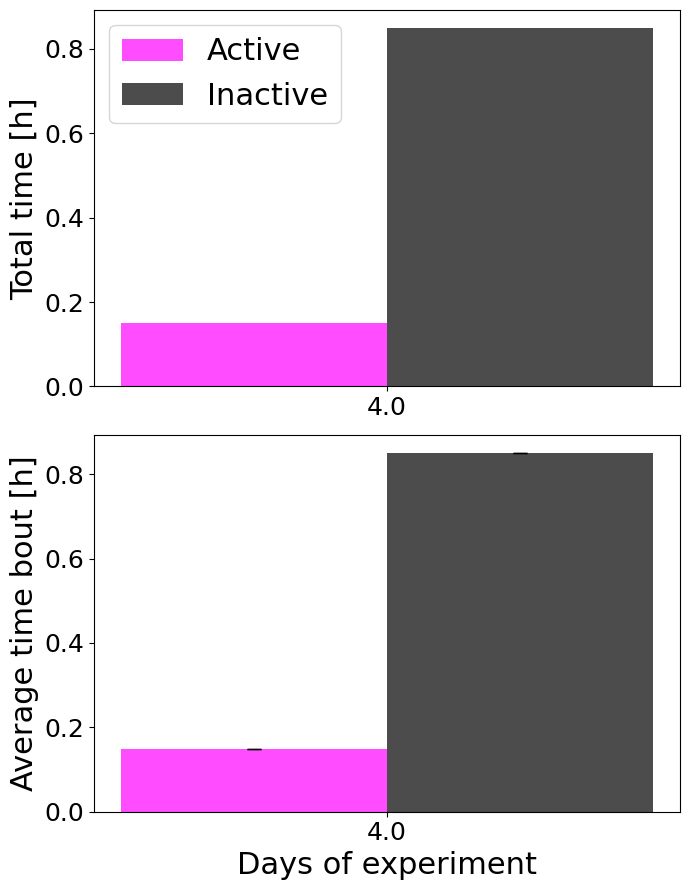

In [35]:
def convolution_filter_with_padding_edge_average(data, length: int=40, iteration: int=1):
  """
  Convolution filter on the signal. This filter is meant to smooth up the signal
  and remove outliers without any threshold. The edges are padded to correct for boundary effects.

  Parameters:
  - length: length of the kernel to convolve on signal. default is 40
  - iteration: number of consecutive convolutions to do. default is 1
  """
  if iteration <= 0:
    raise ValueError("Number of iteration cannot be under 1")

  filtered_data = data.astype(np.float32, copy=False)
  for _ in range(iteration):
    filtered_data = uniform_filter1d(filtered_data, size=length, mode='reflect')

  return filtered_data


def remove_values_under_threshold(time, data, threshold: float=5):
  """
  Remove every data points under a specified threshold.
  Returns the data without the outliers.
  """
  # get all index where condition is met
  # squeeze() ensures that index array is one-dimensional
  positive_values_index = np.argwhere(data >= threshold).squeeze()
  # keep only data_points where condition is met
  new_data = data[positive_values_index]
  new_time = time[positive_values_index]

  return new_time, new_data


def compute_mean_data(time, summed_data, smooth_level: int=3):
  """
  Computes the mean of the mass to smoothen it maximally and only see the tendency of the mass change over time.
  First removes all data points under 10 g.
  Then convolves the data using 600 points.

  smooth_level : The higher, the smoother. Actively, it changes the number of iterations of convolution.

  Returns a tuple of the convolved time and data.
  """
  clean_time, clean_data = remove_values_under_threshold(time=time, data=summed_data, threshold=10)
  convolved_data = convolution_filter_with_padding_edge_average(data=clean_data, length=10000, iteration=smooth_level)
  return clean_time, convolved_data


def plot_raw_mass_time_series(time, data, is_saved, activity_indicators, colors, real_mass, clock_time, time_window, figure_format, night_indicator_list, ground_truth_data=None):
  """
  The summed mass over every timestamp is displayed as well as the smoothened data over time, done with a moving average.
  Automatically downsamples massive 80Hz arrays for memory-safe plotting.
  """
  # Compute mean on the downsampled data (or keep your original convolved data if it's already downsampled)
  convolved_time, convolved_data = compute_mean_data(time=time, summed_data=data, smooth_level=50)

  # Automatic downsampling to prevent RAM chashes
  max_plot_points = 5000000
  if len(time) > max_plot_points:
      step = len(time) // max_plot_points
      plot_time = time[::step]
      plot_data = data[::step]
      plot_activity = activity_indicators[::step]
      # Downsample is_night as well if it matches the length of time
      plot_is_night = is_night[::step] if 'is_night' in locals() or 'is_night' in globals() else None
  else:
      plot_time = time
      plot_data = data
      plot_activity = activity_indicators
      plot_is_night = is_night if 'is_night' in locals() or 'is_night' in globals() else None

  if debug_mode:
    print(f"Original points: {len(time)} | Downsampled plotting points: {len(plot_time)}")

  fig, axs = plt.subplots(1, 1, figsize=(15,10))
  plt.rcParams['pdf.fonttype'] = 42
  plt.rcParams['ps.fonttype'] = 42

  # Plot using the safe, downsampled arrays
  plt.plot(plot_time, plot_data, color="black", linewidth=2, alpha=0.6, label="Raw mass", zorder=4, rasterized=True)
  plt.plot(convolved_time, convolved_data, color="black", linewidth=3, label="Smoothened mass", zorder=5, rasterized=True)
  plt.fill_between(plot_time, np.nanmax(plot_data)+10, where=plot_activity == 1, color='magenta', alpha=0.4, label="Activity indicators", zorder=3, rasterized=True)

  if real_mass is not None:
    plt.scatter(real_mass[0], real_mass[1], marker="*", edgecolors="k", color="y", label="Real mass", s=1000, zorder=4)
  if ground_truth_data is not None:
    plt.fill_between(ground_truth_data[0], np.nanmax(plot_data)+20, where=ground_truth_data[1] == 1, color='red', alpha=0.4, label="Ground truth hanging labels", zorder=2, rasterized=True)

  plt.xlabel("Cumulative time of day [h]", fontsize=50)
  plt.ylabel("Mass [g]", fontsize=50)
  plt.tick_params(axis='both', which='major', labelsize=35)
  plt.ylim(0, 70)

  # Nights background fill
  ax = plt.gca()
  if plot_is_night is not None:
      plt.fill_between(plot_time, 0, 1, where=plot_is_night, color='lightgray', alpha=1, transform=ax.get_xaxis_transform(), label="Night", zorder=1, rasterized=True)

  if is_saved:
    path = Path(data_path)
    figure_path = path.parent / "Figures"
    figure_path.mkdir(parents=True, exist_ok=True)
    file_stem = path.stem
    if time_window is None:
      suffix = "-SumDataWithActivityIndicators." + figure_format
    else:
      suffix = f"-SumDataWithActivityIndicators-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours." + figure_format

    save_path = figure_path / (file_stem + suffix)
    fig.tight_layout()
    plt.savefig(save_path, format=figure_format, dpi=300, transparent=True)
    plt.close(fig)  # Free up memory immediately
  plt.show()


def plot_activity_per_day(activity_per_day, is_saved=False, figure_format="png"):
  """
  Two barr graphs are displayed : the total time of active and inactive events per day and
  the average time of active and inactive bouts per day.
  """
  fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(7,9))
  x = np.array(activity_per_day["All days"])
  axs[0].bar(x, activity_per_day["Active time"], color="magenta", width=0.3, alpha=0.7, label="Active")
  axs[0].bar(x+0.3, activity_per_day["Inactive time"], color="black", width=0.3, alpha=0.7, label="Inactive")
  axs[1].bar(x, activity_per_day["Mean active bouts"], yerr=activity_per_day["Std active bouts"], width=0.3, alpha=0.7, color="magenta", ecolor='black', capsize=5)
  axs[1].bar(x+0.3, activity_per_day["Mean inactive bouts"], yerr=activity_per_day["Std inactive bouts"], width=0.3, alpha=0.7, color="black", ecolor='black', capsize=5)
  print(activity_per_day["Std inactive bouts"])

  x_ticks = x + 0.3/2
  axs[0].set_xticks(x_ticks)
  axs[0].set_xticklabels(x, fontsize=18)
  axs[1].set_xticks(x_ticks)
  axs[1].set_xticklabels(x, fontsize=18)
  axs[0].tick_params(axis='y', labelsize=18)
  axs[1].tick_params(axis='y', labelsize=18)

  plt.xlabel("Days of experiment", fontsize=22)
  axs[0].legend(fontsize=22)
  axs[0].set_ylabel("Total time [h]", fontsize=22)
  axs[1].set_ylabel("Average time bout [h]", fontsize=22)

  fig.tight_layout()

  if is_saved:
    path = Path(data_path)
    figure_path = path.parent / "Figures"
    figure_path.mkdir(parents=True, exist_ok=True)
    file_stem = path.stem
    if time_window is None:
      suffix = "-TotalTimeActiveVSInactive_BoutsActiveInactive_PerDay." + figure_format
    else:
      suffix = f"-TotalTimeActiveVSInactive_BoutsActiveInactive_PerDay-Between{time_window[0]:.3f}and{time_window[1]:.3f}hours-." + figure_format

    save_path = figure_path / (file_stem + suffix)
    fig.tight_layout()
    if figure_format == "png":
      plt.savefig(save_path, format=figure_format, dpi=600, transparent=True, facecolor='white', edgecolor='none')
    else:
      plt.savefig(save_path, format=figure_format, transparent=True, facecolor='white', edgecolor='none')
  plt.show()


if plot_figures:
  if ground_truth_data is None:
    plot_raw_mass_time_series(time=time_in_window_hour, data=summed_data_in_window, activity_indicators=activity_indicators, is_saved=save_figure, colors=color_scales, real_mass=real_mass, clock_time=clock_time, time_window=time_window, figure_format=figure_format, night_indicator_list=night_indicator_list)
  else:
    plot_raw_mass_time_series(ground_truth_data=ground_truth_data, time=time_in_window_hour, activity_indicators=activity_indicators, data=summed_data_in_window, is_saved=save_figure, colors=color_scales, real_mass=real_mass, clock_time=clock_time, time_window=time_window, figure_format=figure_format, night_indicator_list=night_indicator_list)
  plot_activity_per_day(
      activity_per_day=activity_per_day,
      is_saved=save_figure,
      figure_format=figure_format
      )

# 12. Save presence indicators per scale

If `save_data` is True, the mass time series in the selected `time_window` at the selected `days` is saved as well as the presence indicators.

In [36]:
if save_data:
  data ={"Time in time window [h]":time_in_window_hour, "Summed mass in time window":summed_data_in_window, "Activity indicators in time window":activity_indicators, "Night indicator in time window":night_indicator_list}
  df = pd.DataFrame(data)
  path = Path(data_path)
  saved_path = path.parent / "Results of Activity Analysis"
  saved_path.mkdir(parents=True, exist_ok=True)
  file_stem = path.stem
  suffix = save_suffix + "-SummedMass_ActivityIndicator_NightIndicator.csv"
  save_path = saved_path / (file_stem + suffix)
  df.to_csv(save_path)